# Chapter 7: Autoencoders

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Understand **autoencoder** concepts — encoder/decoder architecture, undercomplete vs overcomplete models, dense vs sparse representations, denoising autoencoders, and variational autoencoders (VAEs) — with small TensorFlow 2.x and Keras 3 demos.

---

## What you will learn

1. A short **neural network** primer — layers, weights, activations, and training
2. **TensorFlow 2.x** tensors and a tiny computation demo
3. **Keras 3** as the high-level API (Application Programming Interface) for building models
4. **Autoencoder** building blocks — encoder compresses input; decoder reconstructs it
5. **Undercomplete** vs **overcomplete** bottleneck sizes
6. **Dense** vs **sparse** hidden representations
7. **Denoising autoencoder** — learn to recover clean data from noisy input
8. **Variational autoencoder (VAE)** — probabilistic latent space for generation
9. Preview **MNIST (Modified National Institute of Standards and Technology)** digits — the dataset used hands-on in Chapter 8


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Matplotlib (Mathematical Plotting Library)** | Plot sample digit images |
| **TensorFlow 2.x** | Deep learning backend — tensors, automatic differentiation |
| **Keras 3** | High-level neural network API bundled with TensorFlow |
| **scikit-learn (Scientific Kit for Learning)** | Load MNIST preview subset |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide TensorFlow/sklearn (scikit-learn) warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import os to optionally suppress verbose TensorFlow log messages
import os

# Set TensorFlow log level to errors only (less console noise in teaching demos)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import TensorFlow 2.x — deep learning framework used from Chapter 7 onward in the book
import tensorflow as tf

# Import Keras 3 high-level API from TensorFlow (bundled in TF 2.x)
from tensorflow import keras

# Import MNIST (Modified National Institute of Standards and Technology) loader for preview only
from sklearn.datasets import fetch_openml, load_digits

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Print TensorFlow and Keras versions so learners know their environment
print(f"TensorFlow version: {tf.__version__}")

print(f"Keras version: {keras.__version__}")

# Confirm setup completed without errors
print("Libraries loaded successfully.")


TensorFlow version: 2.21.0
Keras version: 3.14.1
Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Store tensors as NumPy arrays for plotting |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and image display | Preview MNIST digit images |
| **TensorFlow** (`tf`) | Tensors, graphs, automatic gradients | Core deep learning engine |
| **Keras** (`keras`) | `layers`, `models`, `Sequential` | Build neural networks with minimal boilerplate |
| **sklearn.datasets** | Built-in datasets | Load a small MNIST preview |


---

## Algorithms and Concepts Used in This Notebook

### 1. Feedforward Neural Network (basic building block)
- **Type:** Stack of layers that transform input → hidden → output
- **Training:** Minimize a **loss function** (e.g., Mean Squared Error) with an **optimizer** (e.g., Adam)
- **Activation functions:** ReLU (Rectified Linear Unit), sigmoid, linear — introduce nonlinearity or bound outputs

### 2. Autoencoder
- **Type:** Unsupervised neural network for **compression and reconstruction**
- **Encoder:** Maps high-dimensional input **x** to low-dimensional latent code **z**
- **Decoder:** Maps **z** back to reconstructed **x̂** (x-hat)
- **Goal:** Make **x̂ ≈ x** so the bottleneck must capture useful structure

### 3. Undercomplete Autoencoder
- **Bottleneck smaller than input** (e.g., 784 → 32 → 784 for MNIST pixels)
- Forces **lossy compression** — cannot copy input perfectly

### 4. Overcomplete Autoencoder
- **Bottleneck larger than or equal to input dimension**
- Can memorize input unless regularized (dropout, sparsity penalty)

### 5. Sparse Autoencoder
- Adds **activity regularization** so few hidden units fire strongly at once
- Encourages **sparse, interpretable** features

### 6. Denoising Autoencoder
- Trained on **noisy input** but target is **clean original**
- Learns robust features useful for denoising and anomaly detection

### 7. Variational Autoencoder (VAE)
- Latent code is a **probability distribution** (usually Gaussian), not a fixed vector
- Enables **sampling** new data from learned latent space
- Covered conceptually here; full training is in advanced chapters


---

## 1. Neural Networks — Quick Primer

Before autoencoders, recall how a basic **feedforward neural network** works:

| Concept | Meaning |
|---------|--------|
| **Input layer** | Raw features (e.g., 784 pixel values for a 28×28 digit image) |
| **Hidden layer(s)** | Learned transformations — extract patterns |
| **Output layer** | Prediction or reconstruction |
| **Weights & biases** | Learnable parameters updated during training |
| **Loss function** | Measures error (e.g., MSE — Mean Squared Error between prediction and target) |
| **Optimizer** | Algorithm that adjusts weights to reduce loss (e.g., Adam) |
| **Epoch** | One full pass through the training dataset |

**Autoencoders** are neural networks where the **target output equals the input** — the network learns to copy its input through a narrow bottleneck, which forces it to learn a compact representation.


---

## 2. TensorFlow 2.x — Tensors and a Tiny Demo

A **tensor** is a multi-dimensional array — the fundamental data structure in TensorFlow.

| Rank | Example shape | Name |
|------|---------------|------|
| 0 | `()` | Scalar |
| 1 | `(3,)` | Vector |
| 2 | `(2, 3)` | Matrix |
| 3+ | `(28, 28, 1)` | Higher-order (e.g., image batch) |


In [2]:
# Create a 2×2 constant tensor — rank-2 (matrix)
x = tf.constant([[1.0, 2.0], [3.0, 4.0]])

# Print tensor value and shape attribute
print("Tensor x:")

print(x.numpy())

print(f"Shape: {x.shape}  |  dtype: {x.dtype}")

# Element-wise operations on tensors (same idea as NumPy broadcasting)
y = tf.constant([[10.0, 20.0], [30.0, 40.0]])

z = x + y

print("\nx + y:")

print(z.numpy())

# Matrix multiplication — common in neural network layers
product = tf.matmul(x, y)

print("\nMatrix multiply x @ y:")

print(product.numpy())


Tensor x:
[[1. 2.]
 [3. 4.]]
Shape: (2, 2)  |  dtype: <dtype: 'float32'>

x + y:
[[11. 22.]
 [33. 44.]]

Matrix multiply x @ y:
[[ 70. 100.]
 [150. 220.]]


---

## 3. Keras 3 — Building a Small Model

**Keras** provides `keras.layers`, `keras.models`, and `model.compile` / `model.fit` for concise model building.

Below we build a tiny two-layer network on random data — **not** an autoencoder yet, just to show the Keras workflow used throughout Part III of the book.


In [3]:
# Fix random seed for reproducible demo weights
tf.random.set_seed(2018)

# Build a small Sequential model — stack layers top to bottom
demo_model = keras.Sequential([

    # First Dense (fully connected) layer: 2 inputs → 4 hidden units with ReLU (Rectified Linear Unit)
    keras.layers.Dense(4, activation="relu", input_shape=(2,)),

    # Output layer: 4 hidden units → 1 output with linear activation
    keras.layers.Dense(1, activation="linear"),

])

# Compile model — choose loss, optimizer, and optional metrics
demo_model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=0.01),

    loss="mse",

    metrics=["mae"],

)

# Create tiny synthetic training data (4 samples, 2 features each)
X_demo = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=np.float32)

y_demo = np.array([[0.0], [1.0], [1.0], [2.0]], dtype=np.float32)

# Train for 20 epochs — enough to show loss decreasing on toy data
history = demo_model.fit(X_demo, y_demo, epochs=20, verbose=0)

# Show final training loss from history object
print(f"Final training loss (MSE): {history.history['loss'][-1]:.4f}")

# Print model summary — layer names, output shapes, parameter counts
demo_model.summary()


Final training loss (MSE): 0.4829


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (216.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36 (148.00 B)

---

## 4. Autoencoder Concepts

```
Input x  ──►  ENCODER  ──►  Latent code z  ──►  DECODER  ──►  Reconstruction x̂
   (784)         (compress)        (32)           (expand)          (784)
```

Training minimizes reconstruction error: **||x − x̂||²** (squared error, related to MSE loss).


### 4.1 Undercomplete vs Overcomplete

| Type | Bottleneck size | Behavior |
|------|-----------------|----------|
| **Undercomplete** | Fewer units than input (784 → 32) | Must compress — learns principal structure |
| **Overcomplete** | More units than input (784 → 256) | Can copy input exactly unless regularized |

**Chapter 8** trains both types on MNIST digits.


### 4.2 Dense vs Sparse Representations

| Type | Hidden activation pattern | How enforced |
|------|---------------------------|--------------|
| **Dense** | Many units active at once | Default — no extra penalty |
| **Sparse** | Only a few units fire strongly | **Activity regularizer** (L1 penalty on activations) |

Sparse codes resemble how PCA (Principal Component Analysis) and dictionary learning find compact bases — but learned end-to-end by gradient descent.


### 4.3 Denoising Autoencoder

Instead of mapping **x → x**, the model learns **x_noisy → x**.

1. Corrupt input (e.g., add **Gaussian noise** or randomly zero pixels)
2. Train decoder to reconstruct the **clean** original
3. Forces the network to capture **stable structure**, not memorized noise

Useful for: denoising images, robust feature learning, anomaly detection (Chapter 4 connection).


### 4.4 Variational Autoencoder (VAE) — Conceptual Overview

Standard autoencoders map each input to a **fixed** latent vector. **VAEs** map to a **distribution** (mean μ and variance σ² in each latent dimension).

| Standard AE | Variational AE (VAE) |
|-------------|----------------------|
| Deterministic latent code | Probabilistic latent code |
| Good for compression | Good for **generation** and smooth interpolation |
| Loss = reconstruction only | Loss = reconstruction + **KL (Kullback–Leibler) divergence** to regularize latent space |

We do not train a full VAE in this concept chapter — Chapter 8 focuses on classical autoencoder variants. VAEs appear in later deep generative modeling chapters.


---

## 5. Autoencoder Architecture Sketch in Keras (Not Trained)

The cell below defines a **784 → 32 → 784 undercomplete autoencoder** — the same architecture trained hands-on in Chapter 8. Here we only inspect the structure.


In [4]:
# Input dimension for MNIST flattened 28×28 images
INPUT_DIM = 784

# Bottleneck (latent) size — undercomplete because 32 < 784
ENCODING_DIM = 32

# Build encoder half using Functional API (explicit input → output graph)
ae_input = keras.Input(shape=(INPUT_DIM,), name="digit_pixels")

encoded = keras.layers.Dense(ENCODING_DIM, activation="linear", name="encoder")(ae_input)

decoded = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="decoder")(encoded)

# Combine encoder + decoder into one trainable autoencoder model
autoencoder_sketch = keras.Model(ae_input, decoded, name="undercomplete_autoencoder_sketch")

# Show layer topology and parameter count (weights not trained yet)
autoencoder_sketch.summary()

# Count trainable parameters — book discusses model capacity vs bottleneck size
n_params = autoencoder_sketch.count_params()

print(f"\nTotal trainable parameters: {n_params:,}")

print(f"Compression ratio: {INPUT_DIM} → {ENCODING_DIM} ({ENCODING_DIM/INPUT_DIM:.1%} of original size)")


Model: "undercomplete_autoencoder_sketch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ digit_pixels (InputLayer)       │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 50,992
Compression ratio: 784 → 32 (4.1% of original size)


---

## 6. MNIST Preview — Context for Chapter 8

The book uses **MNIST handwritten digits**: 28×28 grayscale images, 784 pixels per image, labels 0–9.

We load a **small preview subset** (500 images) — no training in this chapter, just visualization.


In [5]:
# Set random seed for reproducible subsampling
RANDOM_STATE = 2018

# Small preview count — Chapter 8 uses a larger subset for training
N_PREVIEW = 500

# Try to download MNIST 784 features from OpenML (online ML repository)
try:

    print("Loading MNIST (Modified National Institute of Standards and Technology) preview from OpenML...")

    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

    X_full = mnist.data.astype(np.float32)

    y_full = mnist.target.astype(int)

    rng = np.random.RandomState(RANDOM_STATE)

    idx = rng.choice(len(y_full), size=N_PREVIEW, replace=False)

    X_preview = X_full[idx]

    y_preview = y_full[idx]

    DATA_SOURCE = "MNIST 784 (preview subset)"

except Exception as e:

    print(f"MNIST download failed ({e}). Using sklearn load_digits fallback.")

    digits = load_digits()

    X_preview = digits.data.astype(np.float32)

    y_preview = digits.target.astype(int)

    DATA_SOURCE = "load_digits (8x8 fallback)"

# Scale pixel values to [0, 1] — same preprocessing as Chapter 8
X_preview = X_preview / 255.0

# Report preview dataset shape
print(f"Data source: {DATA_SOURCE}")

print(f"Preview shape: {X_preview.shape}  |  labels: {np.unique(y_preview)}")


Loading MNIST (Modified National Institute of Standards and Technology) preview from OpenML...


Data source: MNIST 784 (preview subset)
Preview shape: (500, 784)  |  labels: [0 1 2 3 4 5 6 7 8 9]


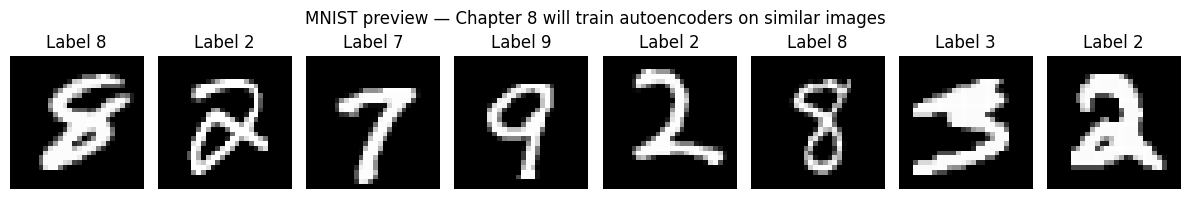

In [6]:
# Visualize sample digits from the preview subset
n_show = 8

fig, axes = plt.subplots(1, n_show, figsize=(12, 2))

side = int(np.sqrt(X_preview.shape[1]))

for ax, i in zip(axes, range(n_show)):

    ax.imshow(X_preview[i].reshape(side, side), cmap="gray", vmin=0, vmax=1)

    ax.set_title(f"Label {y_preview[i]}")

    ax.axis("off")

plt.suptitle("MNIST preview — Chapter 8 will train autoencoders on similar images")

plt.tight_layout()

plt.show()


---

## 7. Glossary — All Chapter 7 Terms

| Term | One-line definition |
|------|---------------------|
| **Neural network** | Stack of layers that learn input→output mappings from data |
| **Tensor** | Multi-dimensional array — TensorFlow's core data type |
| **Keras** | High-level API for building and training neural networks |
| **Dense layer** | Fully connected layer — every input connects to every output |
| **Activation function** | Nonlinearity applied after a layer (ReLU, sigmoid, linear) |
| **Loss function** | Training objective to minimize (e.g., MSE) |
| **Optimizer** | Algorithm that updates weights (e.g., Adam) |
| **Epoch** | One complete pass through the training set |
| **Autoencoder** | Network trained to reconstruct its own input |
| **Encoder** | Compresses input to latent representation |
| **Decoder** | Expands latent code back to reconstruction |
| **Latent code / bottleneck** | Compressed internal representation |
| **Undercomplete autoencoder** | Bottleneck smaller than input — forced compression |
| **Overcomplete autoencoder** | Bottleneck ≥ input size — needs regularization |
| **Sparse autoencoder** | Hidden activations encouraged to be mostly zero |
| **Activity regularizer** | Penalty on layer activations (often L1) for sparsity |
| **Denoising autoencoder** | Reconstructs clean input from deliberately corrupted input |
| **VAE (Variational Autoencoder)** | Probabilistic latent space + KL regularization for generation |
| **MSE (Mean Squared Error)** | Average squared difference between target and prediction |
| **MNIST** | Standard handwritten digit benchmark dataset |


---

## 8. Chapter 7 Summary

```
Autoencoders (Chapter 7) — concepts
├── Neural network primer (layers, loss, optimizer)
├── TensorFlow 2.x tensors + tiny computation
├── Keras 3 Sequential model demo
├── Autoencoder = encoder → bottleneck → decoder
│   ├── Undercomplete (compress) vs overcomplete (regularize)
│   ├── Dense vs sparse hidden codes
│   ├── Denoising (noisy input → clean output)
│   └── VAE (probabilistic latent space) — conceptual
└── MNIST preview for Chapter 8 hands-on

Next: Chapter 8 trains multiple autoencoder variants on MNIST
```

### What's next?

**Chapter 8** builds and compares undercomplete, nonlinear, overcomplete, sparse, and denoising autoencoders on MNIST — with reconstruction MSE (Mean Squared Error) evaluation.

---

### Practice questions

1. Why does an undercomplete autoencoder force the network to learn a compressed representation?
2. What problem can an overcomplete autoencoder have, and how do dropout or sparsity penalties help?
3. How is a denoising autoencoder different from a standard autoencoder in terms of input and target?
4. What extra loss term does a VAE (Variational Autoencoder) add beyond reconstruction error?
5. Why do we scale MNIST pixels to [0, 1] before training neural networks?
